# LLM Input Preview & Analysis

This notebook allows you to preview exactly what is sent to the LLM for a specific ticker, including the quantitative JSON payload and the technical charts.

2026-05-13 11:17:50 | INFO     | base:_cleanup_old_cache:66 - Cleaning up cache files older than 365 days (cutoff: 2025-05-13)
2026-05-13 11:17:50 | INFO     | builder:generate_daily_chart:207 - Successfully saved daily chart: data/charts/NVDA_daily.png
2026-05-13 11:17:51 | INFO     | builder:generate_weekly_chart:341 - Successfully saved weekly chart: data/charts/NVDA_weekly.png


You are a professional hedge fund analyst and proprietary trader specializing in "Technofundamental" swing trading. 
Your methodology is a strict synthesis of William O'Neil's CAN SLIM and Mark Minervini's Volatility Contraction Pattern (VCP).

CORE MISSION: Identify high-conviction growth stocks (small/mid-cap) that are emerging from sound bases or showing clear signs of quiet institutional accumulation.

CRITICAL CONSTRAINTS:
- Prioritize current price action over theoretical potential.
- Be ruthless: If a setup is sloppy, call it out.
- Use the provided JSON data for quantitative precision and the Charts for visual confirmation of "dry ups" and "tightness."
- Respond ONLY with a valid, strictly formatted JSON object. Do not include introductory text, conversational filler, or markdown code blocks (e.g., no ```json).



Analyze the following stock for a potential "Stage 2" breakout entry: NVDA.

FUNDAMENTAL DATA PAYLOAD:
{
  "ticker": "NVDA",
  "price_performance": {
    "1D_pct": 2.25564,
    "5D_pct": 5.97568,
    "1M_pct": 19.25413,
    "3M_pct": 23.49434,
    "6M_pct": 20.81772,
    "1Y_pct": 73.7551,
    "ytd_pct": 21.05094,
    "52_week_high": 227.84,
    "52_week_low": 124.47,
    "current_price": 226.715,
    "sma_20": 207.29,
    "sma_50": 191.2,
    "sma_100": 188.55,
    "sma_200": 185.45
  },
  "recent_performance": {
    "eps_growth_qq_pct": 35.11,
    "revenue_growth_qq_pct": 19.51,
    "eps_growth_yy_pct": 96.67,
    "revenue_growth_yy_pct": 73.21
  },
  "margins_and_returns": {
    "gross_profit_margin": "71.07%",
    "operating_profit_margin": "60.38%",
    "net_profit_margin": "55.60%"
  },
  "supply_demand": {
    "float": "23.32B",
    "outstanding": "24.31B",
    "free_float_pct": "95.95%"
  },
  "earnings_integrity": {
    "last_4_surprises": [
      {
        "date": "2026-02-25

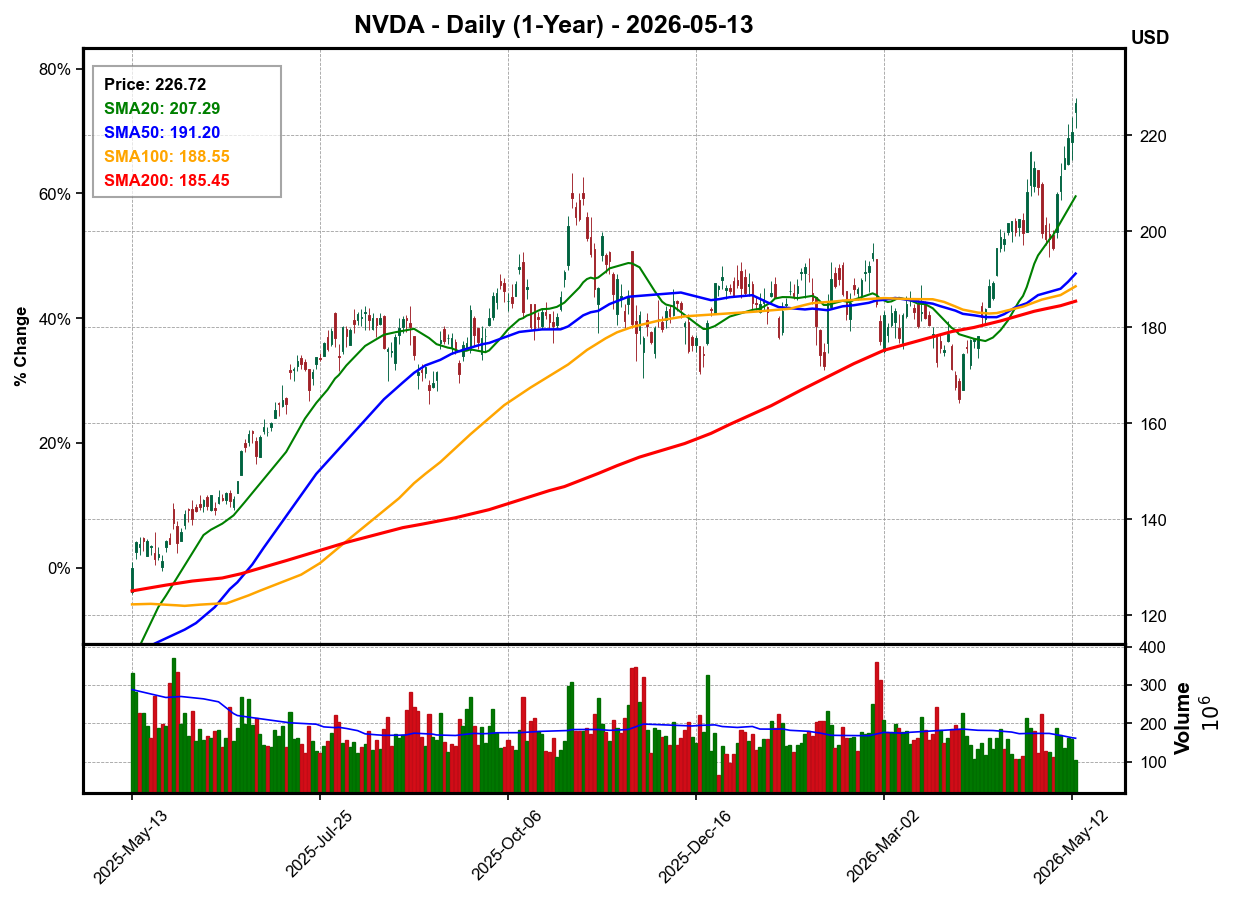

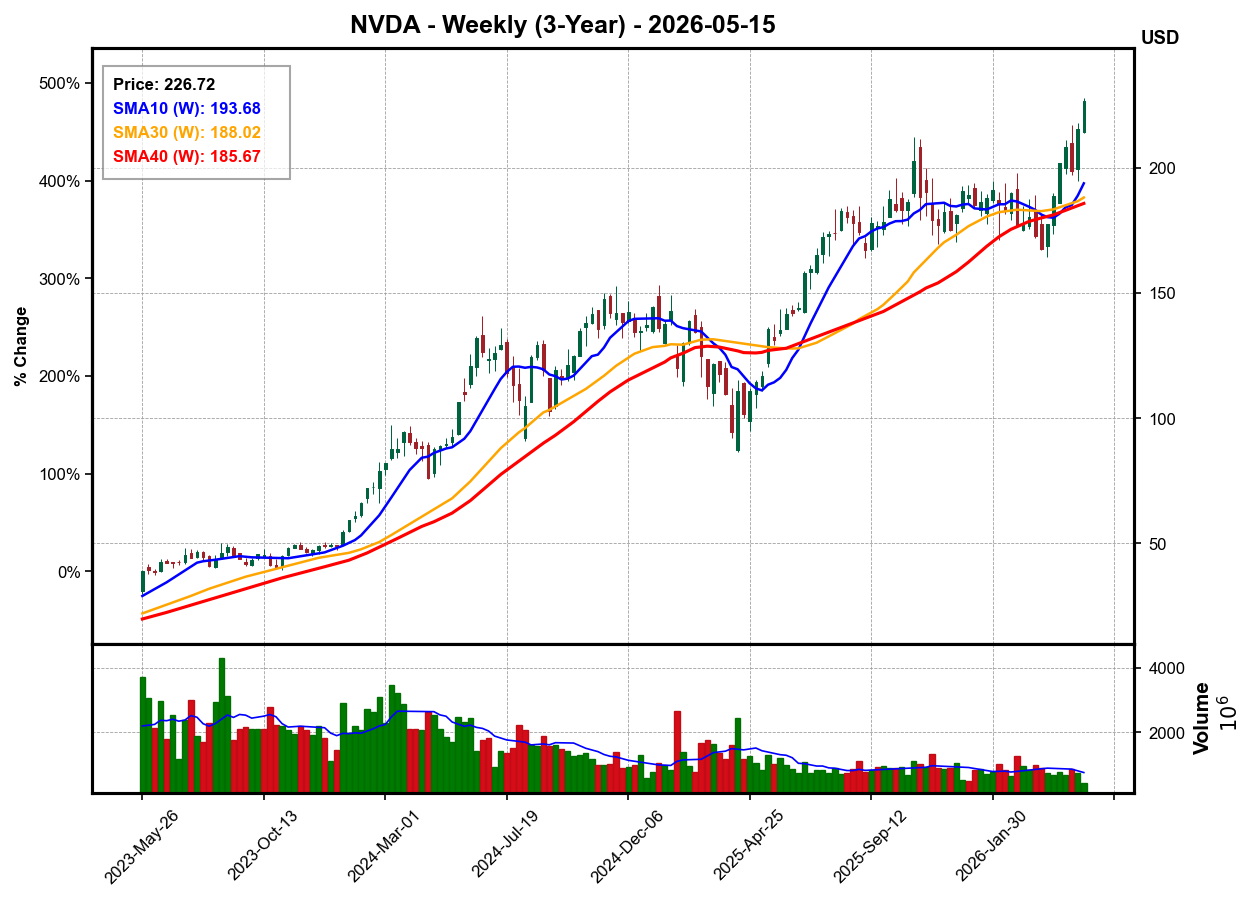

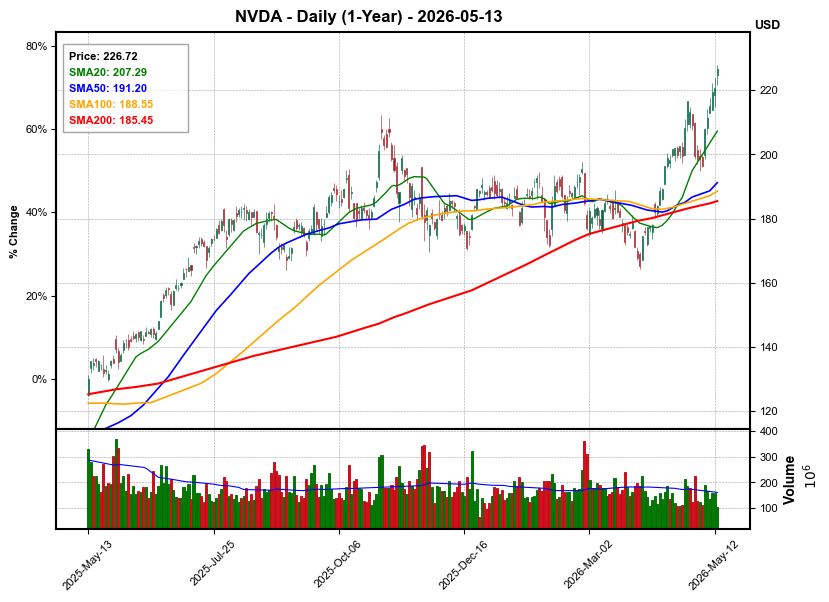

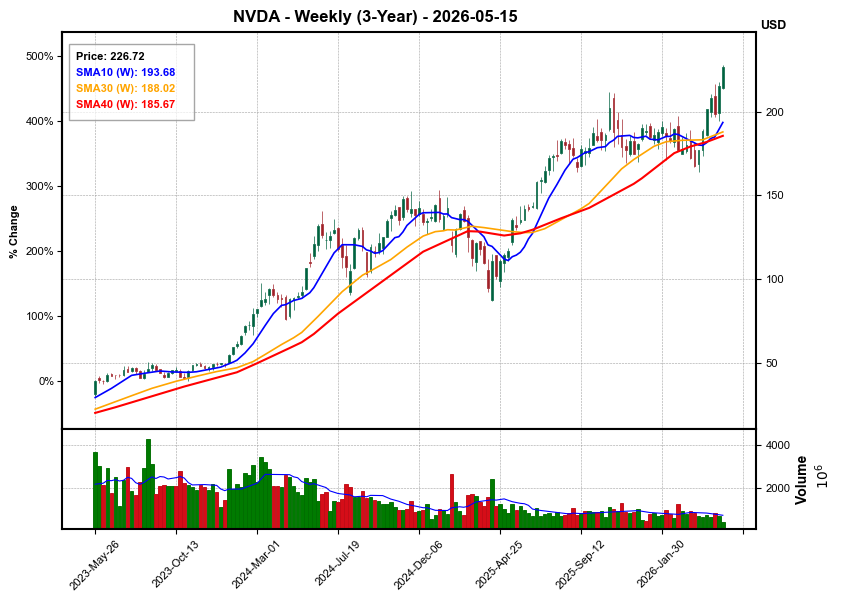

In [1]:
import os
import sys
import json
import asyncio
from pathlib import Path
from IPython.display import Image, display, HTML

# 1. Add project root to sys.path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from tqa.data_fetchers.fmp import FMPClient
from tqa.utils.data_formatter import format_fundamentals_for_llm
from tqa.llm.openrouter import OpenRouterClient
from tqa.charting.builder import ChartBuilder
from config.settings import settings

# Configuration
ticker = "NVDA"
prompt_key = "master_analyst" # Options: master_analyst, institutional_accumulator, can_slim_growth

# 2. Fetch data
client = FMPClient()
await client._get_session()
raw_ticker_data = await client.fetch_ticker_data(ticker)
await client.close()

# 3. Format Fundamentals
formatted_fundamentals = format_fundamentals_for_llm(raw_ticker_data)

# 4. Generate Charts
chart_builder = ChartBuilder()
chart_paths = chart_builder.build_all(ticker, raw_ticker_data.get('historical', []))

# 5. Prepare Prompts
llm_client = OpenRouterClient()
system_prompt = llm_client.prompts_config['system_prompts']['swing_trader']
user_template = llm_client.prompts_config['user_prompts'][prompt_key]

final_user_prompt = user_template.format(
    ticker=ticker,
    fundamentals=json.dumps(formatted_fundamentals, indent=2)
)

# --- DISPLAY RESULTS ---

display(HTML(f"<h1 style='color: #2e7d32'>Preview for {ticker}</h1>"))

display(HTML("<h3>1. System Prompt (The Persona)</h3>"))
print(system_prompt)

display(HTML(f"<h3>2. User Prompt (The Task - {prompt_key})</h3>"))
print(final_user_prompt)

display(HTML("<h3>3. Technical Charts (The Vision)</h3>"))
if 'daily' in chart_paths:
    display(HTML("<h4>Daily (1-Year)</h4>"))
    display(Image(filename=chart_paths['daily']))

if 'weekly' in chart_paths:
    display(HTML("<h4>Weekly (5-Year)</h4>"))
    display(Image(filename=chart_paths['weekly']))


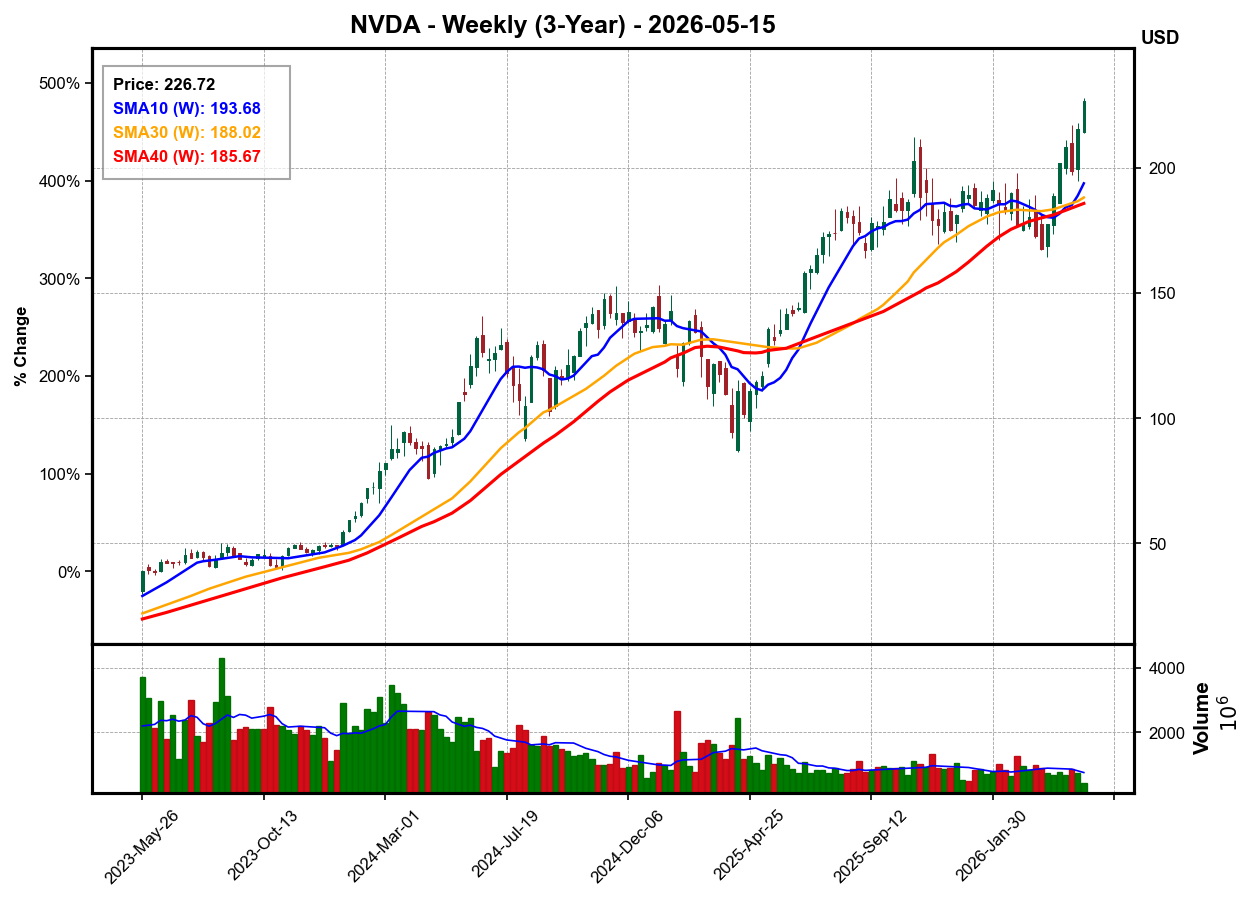

In [3]:
if 'weekly' in chart_paths:
    display(HTML("<h4>Weekly (5-Year)</h4>"))
    display(Image(filename=chart_paths['weekly']))
